# 503: Temperature Contribution Analysis

This notebook calculates the contribution of different forcing components to temperature change
between peak warming year and 2100.

## Approach

For each scenario with `MAGICC_FLAG="ANTHROPOGENIC"`, we calculate:
1. **Peak warming year** and **peak warming magnitude** per ensemble member
2. **Warming in 2100** per ensemble member
3. **Component contributions** (delta from peak to 2100)

### Component Lookup Rules

For a scenario `{scenario}` with `MAGICC_FLAG="ANTHROPOGENIC"`:
- **CO2/GHG**: Look up `{scenario}` with `MAGICC_FLAG=CO2` and `MAGICC_FLAG=GHG`
- **NZCO2** (for ZEC proxy): 
  - If scenario contains `_NZCO2`: use `{scenario}` with `MAGICC_FLAG=CO2`
  - If scenario contains `_NZKyoto`: use `{base}_NZCO2` with `MAGICC_FLAG=CO2` (where base = scenario without `_NZKyoto`)
  - Otherwise: use `{scenario}_NZCO2` with `MAGICC_FLAG=CO2`

### Components Analysed

- **ANTHROPOGENIC**: Total warming (from MAGICC_FLAG=ANTHROPOGENIC)
- **CO2_NZCO2**: CO2 warming if emissions held constant at net-zero level (ZEC proxy)
- **CO2_Negative**: Cooling from negative CO2 emissions (CO2 - CO2_NZCO2)
- **NonCO2_GHG**: Non-CO2 greenhouse gas contribution (GHG - CO2)
- **Residual**: Other forcings (ANTHROPOGENIC - GHG)

## Outputs

- `503_warming_metrics.csv`: Per-run metrics for all scenarios
- `503_waterfall_contributions.png`: Waterfall plots comparing scenario subsets

In [38]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from scipy.stats import gaussian_kde

dotenv.load_dotenv()

# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

# Input metrics file
MANIFEST_ID = "regenerated"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

In [39]:
# Configuration
COMPONENTS = ["ANTHROPOGENIC", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

## Load Data

In [40]:
# Load metrics
metrics_df = pd.read_csv(METRICS_FILE, index_col=0)

## Summary Statistics

In [41]:
# Aggregate by scenario (median only for simplicity)
value_cols = [c for c in metrics_df.columns if c.startswith("GSAT|")]
stats = metrics_df.groupby(["model", "scenario", "scenario_group"])[value_cols].median()
print(f"Statistics for {len(stats)} scenarios")
stats.round(3)

Statistics for 2342 scenarios


GSAT|ANTHROPOGENIC|peak  \
model             scenario                      scenario_group                                            
AIM/CGE 2.0       SSP1-19                       Scenarios (NZCO2)                                 1.568   
                                                Scenarios (NZGHG)                                 1.568   
                  SSP1-19_NZCO2                 Stylised Variants (NZCO2-hold)                    1.568   
                  SSP1-19_NZKyoto               Stylised Variants (NZGHG-hold)                    1.568   
                  SSP2-19                       Scenarios (NZCO2)                                 1.527   
...                                                                                                 ...   
WITCH-GLOBIOM 4.4 CD-LINKS-NPi2020_1000_NZKyoto Stylised Variants (NZGHG-hold)                    1.517   
                  CD-LINKS-NPi2020_400          Scenarios (NZCO2)                                 1.553   
                                                Scenarios (NZGHG)                                 1.553   
                  CD-LINKS-NPi2020_400_NZCO2    Stylised Variants (NZCO2-hold)                    1.556   
                  CD-LINKS-NPi2020_400_NZKyoto  Stylised Variants (NZGHG-hold)                    1.553   

                                                                                GSAT|ANTHROPOGENIC|netzero_co2  \
model             scenario                      scenario_group                                                   
AIM/CGE 2.0       SSP1-19                       Scenarios (NZCO2)                                        1.521   
                                                Scenarios (NZGHG)                                        1.521   
                  SSP1-19_NZCO2                 Stylised Variants (NZCO2-hold)                           1.521   
                  SSP1-19_NZKyoto               Stylised Variants (NZGHG-hold)                           1.521   
                  SSP2-19                       Scenarios (NZCO2)                                        1.499   
...                                                                                                        ...   
WITCH-GLOBIOM 4.4 CD-LINKS-NPi2020_1000_NZKyoto Stylised Variants (NZGHG-hold)                           1.437   
                  CD-LINKS-NPi2020_400          Scenarios (NZCO2)                                        1.538   
                                                Scenarios (NZGHG)                                        1.538   
                  CD-LINKS-NPi2020_400_NZCO2    Stylised Variants (NZCO2-hold)                           1.538   
                  CD-LINKS-NPi2020_400_NZKyoto  Stylised Variants (NZGHG-hold)                           1.538   

                                                                                GSAT|ANTHROPOGENIC|2100  \
model             scenario                      scenario_group                                            
AIM/CGE 2.0       SSP1-19                       Scenarios (NZCO2)                                 1.275   
                                                Scenarios (NZGHG)                                 1.275   
                  SSP1-19_NZCO2                 Stylised Variants (NZCO2-hold)                    1.351   
                  SSP1-19_NZKyoto               Stylised Variants (NZGHG-hold)                    1.300   
                  SSP2-19                       Scenarios (NZCO2)                                 1.183   
...                                                                                                 ...   
WITCH-GLOBIOM 4.4 CD-LINKS-NPi2020_1000_NZKyoto Stylised Variants (NZGHG-hold)                    1.275   
                  CD-LINKS-NPi2020_400          Scenarios (NZCO2)                                 1.271   
                                                Scenarios (NZGHG)                                 1.271   
                  CD-LINKS-N

In [42]:
# Summary of delta contributions, separated by scenario_group
delta_cols = [f"GSAT|{c}|delta_netzero_co2" for c in COMPONENTS 
              if f"GSAT|{c}|delta_netzero_co2" in metrics_df.columns]

for group in metrics_df["scenario_group"].unique():
    group_stats = stats[stats.index.get_level_values("scenario_group") == group]
    delta_summary = group_stats[delta_cols].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    ).T
    delta_summary.index = [
        c.replace("GSAT|", "").replace("|delta_netzero_co2", "") 
        for c in delta_cols
    ]
    print(f"\nComponent contributions — {group} (n={len(group_stats)} scenarios):")
    display(delta_summary.round(3))


Component contributions — Scenarios (NZCO2) (n=784 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC,784.0,-0.129,0.114,-0.555,-0.343,-0.205,-0.111,-0.033,0.010,0.206
CO2_NZCO2,784.0,-0.033,0.019,-0.160,-0.066,-0.045,-0.032,-0.019,-0.009,0.001
CO2_Negative,784.0,-0.076,0.080,-0.467,-0.233,-0.123,-0.054,-0.009,0.000,0.123
NonCO2_GHG,784.0,-0.021,0.038,-0.146,-0.092,-0.045,-0.015,0.005,0.029,0.113
Residual,784.0,0.000,0.038,-0.106,-0.057,-0.025,-0.000,0.021,0.067,0.163



Component contributions — Stylised Variants (NZCO2-hold) (n=784 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC,784.0,-0.055,0.061,-0.307,-0.163,-0.092,-0.047,-0.012,0.024,0.140
CO2_NZCO2,784.0,-0.033,0.019,-0.160,-0.066,-0.045,-0.032,-0.019,-0.009,0.001
CO2_Negative,784.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
NonCO2_GHG,784.0,-0.020,0.038,-0.144,-0.090,-0.044,-0.014,0.006,0.029,0.115
Residual,784.0,-0.001,0.038,-0.110,-0.059,-0.027,-0.001,0.020,0.064,0.160



Component contributions — Stylised Variants (NZGHG-hold) (n=387 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC,387.0,-0.155,0.071,-0.382,-0.275,-0.201,-0.149,-0.107,-0.047,0.025
CO2_NZCO2,387.0,-0.041,0.016,-0.099,-0.071,-0.050,-0.038,-0.029,-0.018,-0.007
CO2_Negative,387.0,-0.095,0.047,-0.312,-0.185,-0.123,-0.087,-0.062,-0.035,-0.010
NonCO2_GHG,387.0,-0.026,0.035,-0.138,-0.076,-0.050,-0.030,-0.008,0.034,0.124
Residual,387.0,0.006,0.044,-0.105,-0.061,-0.025,0.006,0.030,0.078,0.173



Component contributions — Scenarios (NZGHG) (n=387 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC,387.0,-0.203,0.103,-0.555,-0.379,-0.271,-0.193,-0.127,-0.051,0.025
CO2_NZCO2,387.0,-0.041,0.016,-0.099,-0.071,-0.050,-0.038,-0.029,-0.018,-0.007
CO2_Negative,387.0,-0.130,0.076,-0.467,-0.274,-0.174,-0.115,-0.075,-0.036,-0.010
NonCO2_GHG,387.0,-0.038,0.039,-0.146,-0.100,-0.065,-0.037,-0.013,0.023,0.104
Residual,387.0,0.002,0.043,-0.106,-0.065,-0.027,0.004,0.028,0.069,0.163


In [43]:
# Summary of delta contributions, separated by scenario_group
delta_cols = [f"GSAT|{c}|delta_peak_gsat" for c in COMPONENTS 
              if f"GSAT|{c}|delta_peak_gsat" in metrics_df.columns]

for group in metrics_df["scenario_group"].unique():
    group_stats = stats[stats.index.get_level_values("scenario_group") == group]
    delta_summary = group_stats[delta_cols].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    ).T
    delta_summary.index = [
        c.replace("GSAT|", "").replace("|delta_netzero_co2", "") 
        for c in delta_cols
    ]
    print(f"\nComponent contributions — {group} (n={len(group_stats)} scenarios):")
    display(delta_summary.round(3))


Component contributions — Scenarios (NZCO2) (n=784 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC|delta_peak_gsat,784.0,-0.149,0.114,-0.593,-0.360,-0.225,-0.125,-0.056,-0.004,0.000
CO2_NZCO2|delta_peak_gsat,784.0,-0.029,0.020,-0.153,-0.065,-0.042,-0.026,-0.014,0.000,0.000
CO2_Negative|delta_peak_gsat,784.0,-0.074,0.078,-0.449,-0.230,-0.119,-0.050,-0.007,0.000,0.026
NonCO2_GHG|delta_peak_gsat,784.0,-0.032,0.043,-0.197,-0.107,-0.061,-0.023,0.000,0.020,0.085
Residual|delta_peak_gsat,784.0,-0.013,0.033,-0.125,-0.077,-0.034,-0.000,0.005,0.038,0.082



Component contributions — Stylised Variants (NZCO2-hold) (n=784 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC|delta_peak_gsat,784.0,-0.076,0.064,-0.355,-0.195,-0.109,-0.066,-0.025,0.000,0.000
CO2_NZCO2|delta_peak_gsat,784.0,-0.026,0.021,-0.139,-0.064,-0.040,-0.023,-0.009,0.000,0.000
CO2_Negative|delta_peak_gsat,784.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
NonCO2_GHG|delta_peak_gsat,784.0,-0.031,0.040,-0.197,-0.104,-0.059,-0.020,0.000,0.014,0.062
Residual|delta_peak_gsat,784.0,-0.019,0.027,-0.127,-0.078,-0.035,0.000,0.000,0.001,0.026



Component contributions — Stylised Variants (NZGHG-hold) (n=387 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC|delta_peak_gsat,387.0,-0.170,0.077,-0.418,-0.296,-0.219,-0.167,-0.117,-0.052,-0.007
CO2_NZCO2|delta_peak_gsat,387.0,-0.035,0.018,-0.097,-0.068,-0.046,-0.032,-0.021,-0.009,0.000
CO2_Negative|delta_peak_gsat,387.0,-0.091,0.046,-0.293,-0.181,-0.119,-0.082,-0.059,-0.030,-0.008
NonCO2_GHG|delta_peak_gsat,387.0,-0.036,0.042,-0.174,-0.100,-0.068,-0.033,-0.009,0.032,0.108
Residual|delta_peak_gsat,387.0,-0.008,0.035,-0.124,-0.076,-0.028,0.000,0.014,0.041,0.074



Component contributions — Scenarios (NZGHG) (n=387 scenarios):


,count,mean,std,min,5%,25%,50%,75%,95%,max
ANTHROPOGENIC|delta_peak_gsat,387.0,-0.219,0.107,-0.593,-0.390,-0.293,-0.212,-0.137,-0.059,-0.007
CO2_NZCO2|delta_peak_gsat,387.0,-0.035,0.018,-0.097,-0.068,-0.046,-0.032,-0.021,-0.009,0.000
CO2_Negative|delta_peak_gsat,387.0,-0.126,0.076,-0.449,-0.270,-0.169,-0.112,-0.073,-0.031,-0.008
NonCO2_GHG|delta_peak_gsat,387.0,-0.048,0.045,-0.182,-0.116,-0.083,-0.045,-0.015,0.022,0.085
Residual|delta_peak_gsat,387.0,-0.007,0.038,-0.125,-0.080,-0.032,0.002,0.019,0.052,0.082


## Figure 2

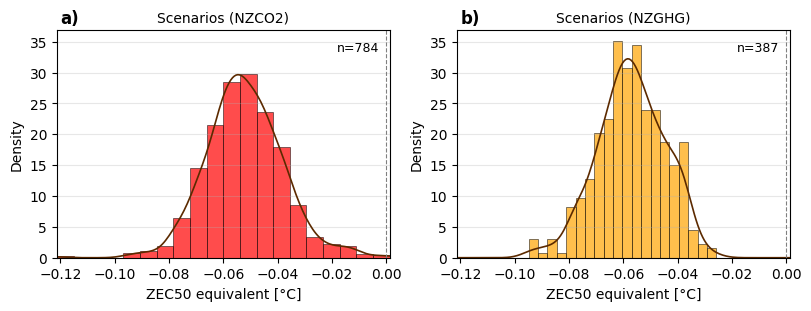

In [44]:
plot_data_all = (
    metrics_df
    .groupby(["model", "scenario", "scenario_group"])[
        ["GSAT|CO2_NZCO2|delta_netzero_co2", "GSAT|ANTHROPOGENIC|peak", "year_netzero_co2"]
    ]
    .median()
    .reset_index()
    .dropna(subset=["GSAT|CO2_NZCO2|delta_netzero_co2", "year_netzero_co2"])
)

plot_data_all["ZEC50"] = (
    plot_data_all["GSAT|CO2_NZCO2|delta_netzero_co2"]
    * 50
    / (2100 - plot_data_all["year_netzero_co2"])
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

groups = ["Scenarios (NZCO2)", "Scenarios (NZGHG)"]
colors = {
    "Scenarios (NZCO2)":          "red",
    "Scenarios (NZGHG)":          "orange",
}

# Compute shared x-axis range across all groups
zec50_all = plot_data_all["ZEC50"].dropna()
x_min, x_max = zec50_all.min(), zec50_all.max()
x_range = np.linspace(x_min, x_max, 200)

for ax, group in zip(axes.flatten(), groups):
    gdata = plot_data_all[plot_data_all["scenario_group"] == group]["ZEC50"].dropna()
    color = colors[group]

    ax.hist(
        gdata,
        bins=20,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.7,
        density=True,
    )

    # KDE overlay
    if len(gdata) > 1:
        kde = gaussian_kde(gdata)
        ax.plot(x_range, kde(x_range), color="#5C2A00", linewidth=1.2)

    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlim(x_min, x_max)
    ax.set_title(group, fontsize=10)
    ax.set_xlabel("ZEC50 equivalent [°C]")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3, axis="y")
    ax.annotate(f"n={len(gdata)}", xy=(0.97, 0.95), xycoords="axes fraction",
                fontsize=9, va="top", ha="right")
# Align y-axis limits across both panels
ymax = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(0, ymax)
    
# Panel labels
for ax, label in zip(axes.flatten(), ["a)", "b)"]):
    ax.annotate(label, xy=(0.01, 1.09), xycoords="axes fraction",
                fontsize=12, fontweight="bold", va="top", ha="left")

#plt.savefig(PLOT_FOLDER / "503_ZEC50_histograms_by_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
from scipy.stats import gaussian_kde

def add_density(ax, data, color):
    data = data.dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    # Scale density to match histogram counts
    ax2 = ax.twinx()
    ax2.plot(x_range, kde(x_range), color=color, linewidth=1.5)
    ax2.set_ylabel("Density")
    ax2.set_ylim(bottom=0)
    return ax2

In [46]:
## stats on the ZEC50 distribution
central = plot_data["ZEC50"].median()
p17 = plot_data["ZEC50"].quantile(0.17)
p83 = plot_data["ZEC50"].quantile(0.83)
print(f"Central value: {central:.3f}, likely range (17th-83rd percentile): {p17:.3f} to {p83:.3f} °C")

KeyError: 'ZEC50'

## Percentile of Percentile Statistics

Calculate the median of medians, p67 of p67, p34 of p34, p5 of p5, p95 of p95 across the delta metrics.

In [47]:
def calc_percentile_of_percentile(scenario_pctl_df, components, extraction_mode="netzero_co2"):
    """Calculate percentile-of-percentile statistics across scenarios."""
    pop = {}
    for comp in components:
        col_base = f"GSAT|{comp}|delta_{extraction_mode}"
        if f"{col_base}|median" in scenario_pctl_df.columns:
            pop[comp] = {
                "median_of_median": scenario_pctl_df[f"{col_base}|median"].median(),
                "p05_of_p05": scenario_pctl_df[f"{col_base}|p05"].quantile(0.05),
                "p17_of_p17": scenario_pctl_df[f"{col_base}|p17"].quantile(0.17),
                "p83_of_p83": scenario_pctl_df[f"{col_base}|p83"].quantile(0.83),
                "p95_of_p95": scenario_pctl_df[f"{col_base}|p95"].quantile(0.95),
            }
    return pop


def calc_pop_by_group(scenario_pctl_df, components, extraction_mode="netzero_co2"):
    """
    Calculate percentile-of-percentile statistics per scenario_group.
    Returns a dict of {group: pop_df}.
    """
    results = {}
    for group, gdf in scenario_pctl_df.groupby(level="scenario_group"):
        pop = calc_percentile_of_percentile(gdf, components, extraction_mode)
        if pop:
            df = pd.DataFrame(pop).T
            df.index.name = "Component"
            results[group] = df
            print(f"\nPercentile of Percentiles — {group} (n={len(gdf)} scenarios):")
            display(df.round(3))
    return results


### for NZCO2 year
# Define delta columns and percentiles to calculate
delta_cols = [f"GSAT|{c}|delta_netzero_co2" for c in COMPONENTS if f"GSAT|{c}|delta_netzero_co2" in metrics_df.columns]
PERCENTILES = {"median": 0.5, "p05": 0.05, "p17": 0.17, "p83": 0.83, "p95": 0.95}

# Calculate per-scenario percentiles for each delta column
scenario_percentiles = metrics_df.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
    [lambda x, q=q: x.quantile(q) for q in PERCENTILES.values()]
)
scenario_percentiles.columns = [f"{col}|{name}" for col in delta_cols for name in PERCENTILES.keys()]

print(f"Calculated percentiles for {len(scenario_percentiles)} scenarios")
scenario_percentiles.head(10)

pop_by_group_netzero_co2 = calc_pop_by_group(scenario_percentiles, COMPONENTS, "netzero_co2")


### for peak GSAT year
# Define delta columns and percentiles to calculate
delta_cols = [f"GSAT|{c}|delta_peak_gsat" for c in COMPONENTS if f"GSAT|{c}|delta_peak_gsat" in metrics_df.columns]
PERCENTILES = {"median": 0.5, "p05": 0.05, "p17": 0.17, "p83": 0.83, "p95": 0.95}

# Calculate per-scenario percentiles for each delta column
scenario_percentiles = metrics_df.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
    [lambda x, q=q: x.quantile(q) for q in PERCENTILES.values()]
)
scenario_percentiles.columns = [f"{col}|{name}" for col in delta_cols for name in PERCENTILES.keys()]

print(f"Calculated percentiles for {len(scenario_percentiles)} scenarios")
scenario_percentiles.head(10)

pop_by_group_peak_gsat = calc_pop_by_group(scenario_percentiles, COMPONENTS, "peak_gsat")

Calculated percentiles for 2342 scenarios

Percentile of Percentiles — Scenarios (NZCO2) (n=784 scenarios):


,median_of_median,p05_of_p05,p17_of_p17,p83_of_p83,p95_of_p95
Component,,,,,
ANTHROPOGENIC,-0.111,-0.497,-0.311,0.035,0.180
CO2_NZCO2,-0.032,-0.151,-0.092,0.036,0.131
CO2_Negative,-0.054,-0.332,-0.187,-0.000,0.002
NonCO2_GHG,-0.015,-0.131,-0.074,0.022,0.063
Residual,-0.000,-0.096,-0.055,0.086,0.226



Percentile of Percentiles — Scenarios (NZGHG) (n=387 scenarios):


,median_of_median,p05_of_p05,p17_of_p17,p83_of_p83,p95_of_p95
Component,,,,,
ANTHROPOGENIC,-0.193,-0.540,-0.372,-0.024,0.115
CO2_NZCO2,-0.038,-0.161,-0.097,0.040,0.135
CO2_Negative,-0.115,-0.383,-0.236,-0.046,-0.025
NonCO2_GHG,-0.037,-0.147,-0.095,0.010,0.058
Residual,0.004,-0.102,-0.059,0.109,0.242



Percentile of Percentiles — Stylised Variants (NZCO2-hold) (n=784 scenarios):


...

,median_of_median,p05_of_p05,p17_of_p17,p83_of_p83,p95_of_p95
Component,,,,,
ANTHROPOGENIC,-0.212,-0.557,-0.408,-0.042,0.000
CO2_NZCO2,-0.032,-0.167,-0.104,0.028,0.091
CO2_Negative,-0.112,-0.367,-0.233,-0.043,0.000
NonCO2_GHG,-0.045,-0.174,-0.124,0.009,0.048
Residual,0.002,-0.135,-0.078,0.070,0.152



Percentile of Percentiles — Stylised Variants (NZCO2-hold) (n=784 scenarios):


,median_of_median,p05_of_p05,p17_of_p17,p83_of_p83,p95_of_p95
Component,,,,,
ANTHROPOGENIC,-0.066,-0.331,-0.220,0.000,0.000
CO2_NZCO2,-0.023,-0.156,-0.100,0.002,0.061
CO2_Negative,0.000,0.000,0.000,0.000,0.000
NonCO2_GHG,-0.020,-0.160,-0.103,0.014,0.045
Residual,0.000,-0.135,-0.080,0.033,0.091



Percentile of Percentiles — Stylised Variants (NZGHG-hold) (n=387 scenarios):


,median_of_median,p05_of_p05,p17_of_p17,p83_of_p83,p95_of_p95
Component,,,,,
ANTHROPOGENIC,-0.167,-0.453,-0.322,-0.017,0.000
CO2_NZCO2,-0.032,-0.167,-0.104,0.023,0.085
CO2_Negative,-0.082,-0.248,-0.161,-0.034,0.000
NonCO2_GHG,-0.033,-0.160,-0.103,0.012,0.064
Residual,0.000,-0.133,-0.074,0.069,0.154


## Waterfall Plots

Waterfall plots showing contribution of each component to temperature decline from peak to 2100.

In [48]:
# Calculate scenario-level medians for peak and 2100 (needed for waterfall endpoints)
value_cols = [c for c in metrics_df.columns if c.startswith("GSAT|")]
scenario_medians = metrics_df.groupby(["model", "scenario", "scenario_group"])[value_cols].median()

# Filter to Base scenarios using scenario_group column
scenario_medians_nzco2 = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Scenarios (NZCO2)"
]

# Filter to NZKyoto_syn scenarios using scenario_group column
scenario_medians_nzco2_syn = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Stylised Variants (NZCO2-hold)"
]

# Filter to NZKyoto scenarios using scenario_group column
scenario_medians_nzkyoto = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Scenarios (NZGHG)"
]

# Filter to NZKyoto_syn scenarios using scenario_group column
scenario_medians_nzkyoto_syn = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Stylised Variants (NZGHG-hold)"
]

print(f"All scenarios: {len(scenario_medians)}")
print(f"  Peak (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  NZCO2 (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|netzero_co2'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero CO2 scenarios: {len(scenario_medians_nzco2)}")
print(f"  Peak (median of medians): {scenario_medians_nzco2['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  NZCO2 (median of medians): {scenario_medians_nzco2['GSAT|ANTHROPOGENIC|netzero_co2'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzco2['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero CO2_syn scenarios: {len(scenario_medians_nzco2_syn)}")
print(f"  Peak (median of medians): {scenario_medians_nzco2_syn['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  NZCO2 (median of medians): {scenario_medians_nzco2_syn['GSAT|ANTHROPOGENIC|netzero_co2'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzco2_syn['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero Kyoto scenarios: {len(scenario_medians_nzkyoto)}")
print(f"  Peak (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  NZCO2 (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|netzero_co2'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero Kyoto_syn scenarios: {len(scenario_medians_nzkyoto_syn)}")
print(f"  Peak (median of medians): {scenario_medians_nzkyoto_syn['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  NZCO2 (median of medians): {scenario_medians_nzkyoto_syn['GSAT|ANTHROPOGENIC|netzero_co2'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzkyoto_syn['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

All scenarios: 2342
  Peak (median of medians): 1.835 °C
  NZCO2 (median of medians): 1.810 °C
  2100 (median of medians): 1.694 °C

Net-zero CO2 scenarios: 784
  Peak (median of medians): 1.832 °C
  NZCO2 (median of medians): 1.806 °C
  2100 (median of medians): 1.677 °C

Net-zero CO2_syn scenarios: 784
  Peak (median of medians): 1.835 °C
  NZCO2 (median of medians): 1.806 °C
  2100 (median of medians): 1.759 °C

Net-zero Kyoto scenarios: 387
  Peak (median of medians): 1.840 °C
  NZCO2 (median of medians): 1.825 °C
  2100 (median of medians): 1.621 °C

Net-zero Kyoto_syn scenarios: 387
  Peak (median of medians): 1.840 °C
  NZCO2 (median of medians): 1.825 °C
  2100 (median of medians): 1.676 °C


In [49]:
def create_waterfall_plot(pop_stats, scenario_medians_subset, title, ax):
    # Colors
    color_start = '#2C5F7C'
    color_delta = {
        'CO2_NZCO2': '#8B4513',
        'CO2_Negative': '#228B22',
        'NonCO2_GHG': '#FF8C00',
        'Residual': '#9370DB'
    }
    color_end = '#2E8B57'


    color_start = '#0F0FFF'
    color_delta = {
        'CO2_NZCO2': '#FF0B00',
        'CO2_Negative': '#00E3DB',
        'NonCO2_GHG': '#4CA2FF',
        'Residual': '#C92EB9'
    }
    color_end = '#0F0FFF'

    # Error bar styling
    error_kw = {'ecolor': 'black', 'alpha': 0.5, 'capsize': 4, 'capthick': 1.2}
    
    # Bar styling
    bar_kw = {'width': 0.6, 'edgecolor': 'black', 'linewidth': 0.8}

    # Calculate peak and 2100 statistics
    nzco2_median = scenario_medians_subset["GSAT|ANTHROPOGENIC|netzero_co2"].median()
    nzco2_p17 = scenario_medians_subset["GSAT|ANTHROPOGENIC|netzero_co2"].quantile(0.17)
    nzco2_p83 = scenario_medians_subset["GSAT|ANTHROPOGENIC|netzero_co2"].quantile(0.83)

    peak_median = scenario_medians_subset["GSAT|ANTHROPOGENIC|peak"].median()
    peak_p17 = scenario_medians_subset["GSAT|ANTHROPOGENIC|peak"].quantile(0.17)
    peak_p83 = scenario_medians_subset["GSAT|ANTHROPOGENIC|peak"].quantile(0.83)
    
    y2100_median = scenario_medians_subset["GSAT|ANTHROPOGENIC|2100"].median()
    y2100_p17 = scenario_medians_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.17)
    y2100_p83 = scenario_medians_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.83)
    
    # Bar positions
    x_positions = [0, 1, 2, 3, 4, 5]
    labels = ["NZCO2 [ANTHROPOGENIC]", "ZEC*", "CO$_2$\nNeg", "Non-CO$_2$\nGHG", "Resid.", "2100\n[ANTHROPOGENIC]"]
    
    # Plot peak bar
    ax.bar(0, nzco2_median, color=color_start,
           yerr=[[nzco2_median - nzco2_p17], [nzco2_p83 - nzco2_median]],
           error_kw=error_kw, **bar_kw)
    
    # Plot delta bars (stacked waterfall)
  #  bottom = peak_median
    bottom = nzco2_median
    delta_components = ['CO2_NZCO2', 'CO2_Negative', 'NonCO2_GHG', 'Residual']
    
    for i, comp in enumerate(delta_components):
        if comp in pop_stats.index:
            delta_med = pop_stats.loc[comp, "median_of_median"]
            delta_p17 = pop_stats.loc[comp, "p17_of_p17"]
            delta_p83 = pop_stats.loc[comp, "p83_of_p83"]
            
            ax.bar(i + 1, delta_med, bottom=bottom, color=color_delta[comp],
                   yerr=[[delta_med - delta_p17], [delta_p83 - delta_med]],
                   error_kw=error_kw, **bar_kw)
            bottom += delta_med
    
    # Plot 2100 bar
    ax.bar(5, y2100_median, color=color_end,
           yerr=[[y2100_median - y2100_p17], [y2100_p83 - y2100_median]],
           error_kw=error_kw, **bar_kw)
    
    # Formatting
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel("GSAT (°C)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

    return ax

In [50]:
pop_by_group_netzero_co2

{'Scenarios (NZCO2)':                median_of_median  p05_of_p05  p17_of_p17  p83_of_p83  \
 Component                                                             
 ANTHROPOGENIC         -0.111048   -0.496874   -0.310966    0.034803   
 CO2_NZCO2             -0.031889   -0.150750   -0.091580    0.036319   
 CO2_Negative          -0.053856   -0.331711   -0.187213   -0.000019   
 NonCO2_GHG            -0.014873   -0.130971   -0.074218    0.021656   
 Residual              -0.000471   -0.096476   -0.054839    0.086305   
 
                p95_of_p95  
 Component                  
 ANTHROPOGENIC    0.180448  
 CO2_NZCO2        0.131279  
 CO2_Negative     0.001549  
 NonCO2_GHG       0.063009  
 Residual         0.225884  ,
 'Scenarios (NZGHG)':                median_of_median  p05_of_p05  p17_of_p17  p83_of_p83  \
 Component                                                             
 ANTHROPOGENIC         -0.192568   -0.540348   -0.372091   -0.023953   
 CO2_NZCO2             -0.037512

achieve + maintain NZCO2:
ZEC: -0.05 °C
negative CO2: -
non-CO2 GHGs: -0.03 °C
Residual: 0.03 °C

achieve + maintain NZGHG:
ZEC: -0.06 °C
negative CO2: -0.08 °C
non-CO2 GHGs: -0.04 °C
Residual: 0.04 °C

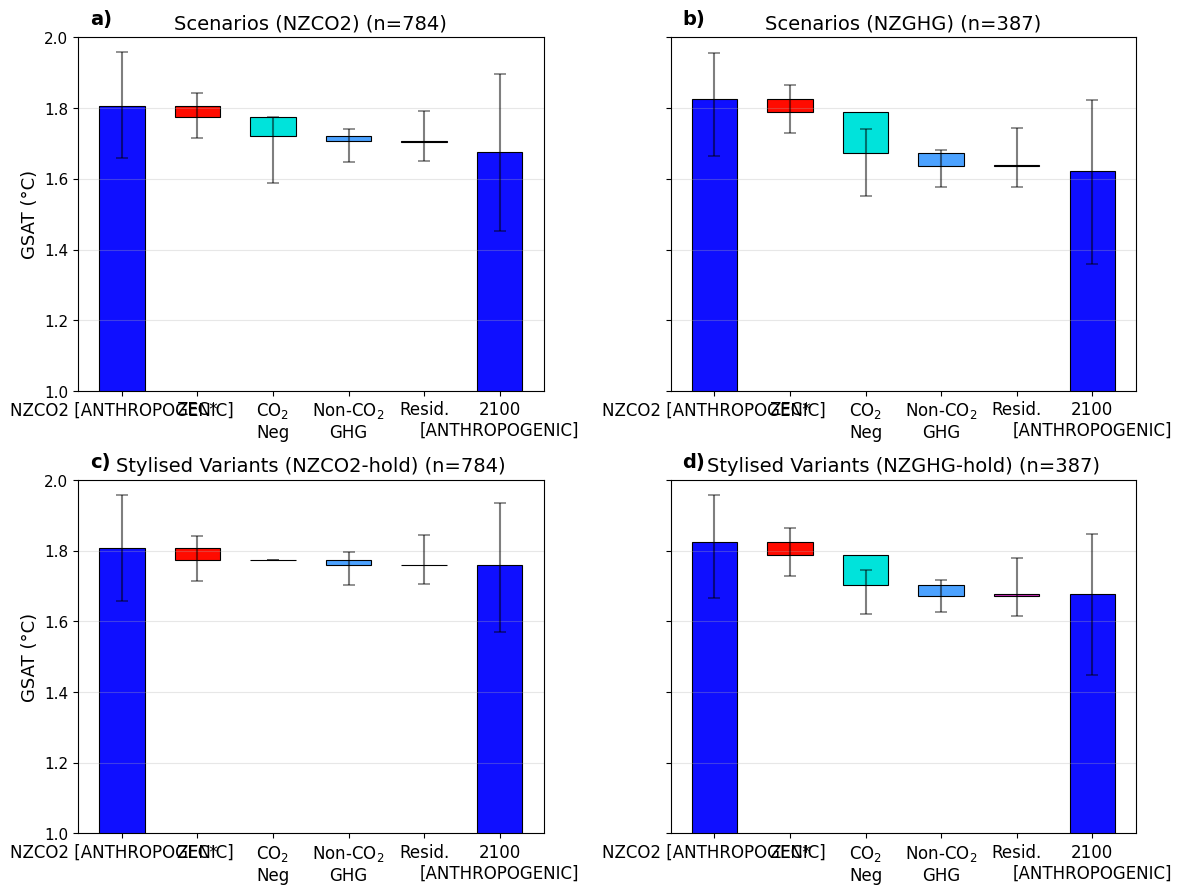

In [51]:
pop_by_group = pop_by_group_netzero_co2
#pop_by_group = pop_by_group_peak_gsat


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()  # convert 2x2 array to flat array of 4 axes

groups = ["Scenarios (NZCO2)", "Scenarios (NZGHG)", "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZGHG-hold)"]
scenario_medians_by_group = {
    "Scenarios (NZCO2)": scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Scenarios (NZCO2)"],
    "Scenarios (NZGHG)": scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Scenarios (NZGHG)"],
    "Stylised Variants (NZCO2-hold)": scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Stylised Variants (NZCO2-hold)"],
    "Stylised Variants (NZGHG-hold)": scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Stylised Variants (NZGHG-hold)"],
}

for ax, group in zip(axes, groups):
    create_waterfall_plot(
        pop_by_group[group],
        scenario_medians_by_group[group],
        f"{group} (n={len(scenario_medians_by_group[group])})",
        ax
    )

# Only left-hand panels need y-axis label
for ax in axes[1::2]:  # axes 1 and 3 (right column)
    ax.set_ylabel("")
    ax.set_ylim(1,2)

plt.tight_layout()

# Add panel labels
labels_ab = ["a)", "b)", "c)", "d)"]
for ax, label in zip(axes, labels_ab):
    x = ax.get_position().x0
    y = ax.get_position().y1
    fig.text(x + 0.01, y + 0.01, label, fontsize=14, fontweight="bold", va="bottom")

plt.savefig(PLOT_FOLDER / "503_waterfall_contributions_nzco2_1.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
ZEC50_values = { "ZEC50=-0.19": -0.19, "ZEC50=0": 0.0, "ZEC50=+0.19": 0.19}
PEAK_YEAR_THRESHOLD = 2100
DELTA_WARMING_THRESHOLD = 0.0

results = []

for zec50_label, zec50_val in ZEC50_values.items():
    df = metrics_df.copy()

    df["ZEC_star_substituted"] = (
        zec50_val * (2100 - df["year_netzero_co2"]) / 50
    )
    df["GSAT|ANTHROPOGENIC|2100_substituted"] = (
        df["GSAT|ANTHROPOGENIC|2100"]
        - df["GSAT|CO2_NZCO2|delta_netzero_co2"]
        + df["ZEC_star_substituted"]
    )
    df["delta_substituted"] = (
        df["GSAT|ANTHROPOGENIC|2100_substituted"] - df["GSAT|ANTHROPOGENIC|netzero_co2"]
    )
    df["is_decline"] = (
        (df["peak_year"] < PEAK_YEAR_THRESHOLD) &
        (df["delta_substituted"] < -DELTA_WARMING_THRESHOLD)
    )

    for group, gdf in df.groupby("scenario_group"):
        scen_stats = gdf.groupby(["model", "scenario"]).agg(
            gsat_2100_sub=("GSAT|ANTHROPOGENIC|2100_substituted", "median"),
            pct_decline=("is_decline", "mean"),
        )
        results.append({
            "ZEC50": zec50_label,
            "scenario_group": group,
            "n_scenarios": len(scen_stats),
            "median_2100": scen_stats["gsat_2100_sub"].median(),
            "p17_2100": scen_stats["gsat_2100_sub"].quantile(0.17),
            "p83_2100": scen_stats["gsat_2100_sub"].quantile(0.83),
            "pct_decline": (scen_stats["pct_decline"] > 0.5).mean() * 100,
        })

sensitivity_df = pd.DataFrame(results).sort_values(["scenario_group"])
print(sensitivity_df.to_string())

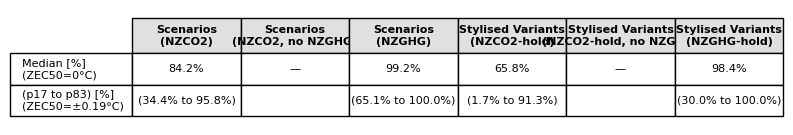

In [21]:
# Build the table data
groups = ["Scenarios (NZCO2)", "Scenarios (NZCO2, no NZGHG)", "Scenarios (NZGHG)", 
          "Stylised Variants (NZCO2-hold)", "Stylised Variants (NZCO2-hold, no NZGHG)", "Stylised Variants (NZGHG-hold)"]

pivot = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_decline")

def format_decline_cell(row):
    return [
        f"{row['ZEC50=0']:.1f}%",
        f"({row['ZEC50=+0.19']:.1f}% to {row['ZEC50=-0.19']:.1f}%)",
    ]

rows = []
for stat_label, val_idx in [
    ("Median [%]\n(ZEC50=0°C)", 0),
    ("(p17 to p83) [%]\n(ZEC50=±0.19°C)", 1),
]:
    row = {"Statistic": stat_label}
    for grp in groups:
        if grp in pivot.index:
            vals = format_decline_cell(pivot.loc[grp])
        else:
            vals = ["—", ""]
        row[grp] = vals[val_idx]
    rows.append(row)

decline_table = pd.DataFrame(rows).set_index("Statistic")

rename_map = {
    "Scenarios (NZCO2)":         "Scenarios\n(NZCO2)",
    "Scenarios (NZCO2, no NZGHG)":         "Scenarios\n(NZCO2, no NZGHG)",
    "Scenarios (NZGHG)":         "Scenarios\n(NZGHG)",
    "Stylised Variants (NZCO2-hold)": "Stylised Variants\n(NZCO2-hold)",
    "Stylised Variants (NZCO2-hold, no NZGHG)": "Stylised Variants\n(NZCO2-hold, no NZGHG)",
    "Stylised Variants (NZGHG-hold)": "Stylised Variants\n(NZGHG-hold)",
}

# Apply rename map to columns
decline_table.columns = decline_table.columns.map(rename_map)

# Plot
fig, ax = plt.subplots(figsize=(7, len(decline_table) * 0.5 + 0.5))
ax.axis("off")
table = ax.table(
    cellText=decline_table.values,
    colLabels=decline_table.columns,
    rowLabels=list(decline_table.index),
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.9)

header_height = 0.3
for col_idx in range(len(decline_table.columns)):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

fig.savefig(PLOT_FOLDER / "503_decline_sensitivity_table_019.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)

In [22]:
results = []

for zec50_label, zec50_val in ZEC50_values.items():
    df = metrics_df.copy()
    df["ZEC_star_substituted"] = (
        zec50_val * (2100 - df["year_netzero_co2"]) / 50
    )
    df["GSAT|ANTHROPOGENIC|2100_substituted"] = (
        df["GSAT|ANTHROPOGENIC|2100"]
        - df["GSAT|CO2_NZCO2|delta_netzero_co2"]
        + df["ZEC_star_substituted"]
    )
    df["delta_substituted"] = (
        df["GSAT|ANTHROPOGENIC|2100_substituted"] - df["GSAT|ANTHROPOGENIC|netzero_co2"]
    )
    df["is_decline"] = (
        (df["peak_year"] < PEAK_YEAR_THRESHOLD) &
        (df["delta_substituted"] < -DELTA_WARMING_THRESHOLD)
    )
    for group, gdf in df.groupby("scenario_group"):
        scen_stats = gdf.groupby(["model", "scenario"]).agg(
            gsat_2100_sub=("GSAT|ANTHROPOGENIC|2100_substituted", "median"),
            pct_decline=("is_decline", "mean"),
        )
        results.append({
            "ZEC50": zec50_label,
            "scenario_group": group,
            "n_scenarios": len(scen_stats),
            "median_2100": scen_stats["gsat_2100_sub"].median(),
            "p17_2100": scen_stats["gsat_2100_sub"].quantile(0.17),
            "p83_2100": scen_stats["gsat_2100_sub"].quantile(0.83),
            "pct_decline_median": scen_stats["pct_decline"].median() * 100,
            "pct_scenarios_gt50": (scen_stats["pct_decline"] > 0.50).mean() * 100,
            "pct_scenarios_gt66": (scen_stats["pct_decline"] > 0.66).mean() * 100,
            "pct_scenarios_gt90": (scen_stats["pct_decline"] > 0.90).mean() * 100,
        })

sensitivity_df = pd.DataFrame(results).sort_values(["scenario_group"])

pivot_median = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_decline_median")
pivot_gt50 = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_scenarios_gt50")
pivot_gt66 = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_scenarios_gt66")
pivot_gt90 = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_scenarios_gt90")

def format_decline_cell(row_median, row_gt50, row_gt66, row_gt90):
    return [
        f"{row_median['ZEC50=0']:.1f}%",
        f"({row_median['ZEC50=+0.19']:.1f}% to {row_median['ZEC50=-0.19']:.1f}%)",
        f"{row_gt50['ZEC50=0']:.1f}%",
        f"({row_gt50['ZEC50=+0.19']:.1f}% to {row_gt50['ZEC50=-0.19']:.1f}%)",
        f"{row_gt66['ZEC50=0']:.1f}%",
        f"({row_gt66['ZEC50=+0.19']:.1f}% to {row_gt66['ZEC50=-0.19']:.1f}%)",
        f"{row_gt90['ZEC50=0']:.1f}%",
        f"({row_gt90['ZEC50=+0.19']:.1f}% to {row_gt90['ZEC50=-0.19']:.1f}%)",
    ]

stat_labels = [
    "Median member decline [%]\n(ZEC50=0°C)",
    "(ZEC50=+0.19 to −0.19°C)",
    "Scenarios >50% declining [%]\n(ZEC50=0°C)",
    "(ZEC50=+0.19 to −0.19°C)",
    "Scenarios >66% declining [%]\n(ZEC50=0°C)",
    "(ZEC50=+0.19 to −0.19°C)",
    "Scenarios >90% declining [%]\n(ZEC50=0°C)",
    "(ZEC50=+0.19 to −0.19°C)",
]

rows = []
for stat_label, val_idx in zip(stat_labels, range(len(stat_labels))):
    row = {"Statistic": stat_label}
    for grp in groups:
        if grp in pivot_median.index:
            vals = format_decline_cell(
                pivot_median.loc[grp],
                pivot_gt50.loc[grp],
                pivot_gt66.loc[grp],
                pivot_gt90.loc[grp],
            )
        else:
            vals = ["—"] * len(stat_labels)
        row[grp] = vals[val_idx]
    rows.append(row)

decline_table = pd.DataFrame(rows).set_index("Statistic")
decline_table.columns = decline_table.columns.map(rename_map)

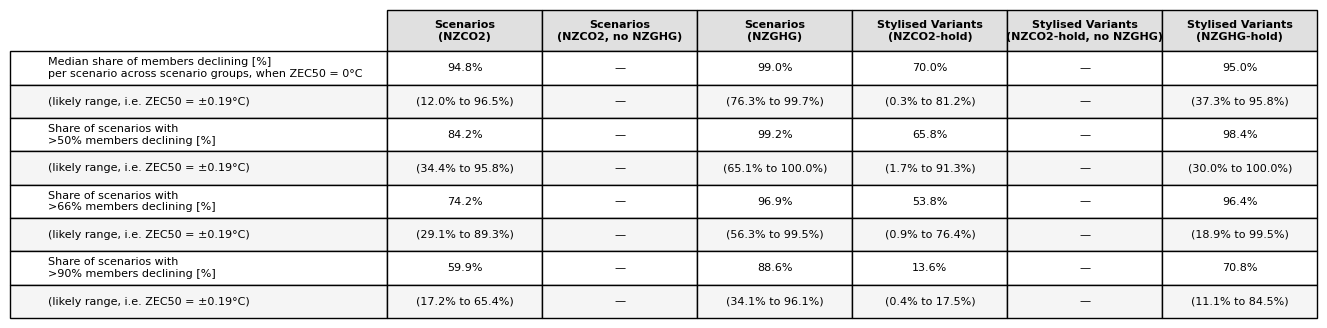

In [23]:
pivot_median = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_decline_median")
pivot_gt50 = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_scenarios_gt50")
pivot_gt66 = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_scenarios_gt66")
pivot_gt90 = sensitivity_df.pivot(index="scenario_group", columns="ZEC50", values="pct_scenarios_gt90")

def format_decline_cell(row_median, row_gt50, row_gt66, row_gt90):
    return [
        f"{row_median['ZEC50=0']:.1f}%",
        f"({row_median['ZEC50=+0.19']:.1f}% to {row_median['ZEC50=-0.19']:.1f}%)",
        f"{row_gt50['ZEC50=0']:.1f}%",
        f"({row_gt50['ZEC50=+0.19']:.1f}% to {row_gt50['ZEC50=-0.19']:.1f}%)",
        f"{row_gt66['ZEC50=0']:.1f}%",
        f"({row_gt66['ZEC50=+0.19']:.1f}% to {row_gt66['ZEC50=-0.19']:.1f}%)",
        f"{row_gt90['ZEC50=0']:.1f}%",
        f"({row_gt90['ZEC50=+0.19']:.1f}% to {row_gt90['ZEC50=-0.19']:.1f}%)",
    ]

stat_labels = [
    "Median share of members declining [%]\nper scenario across scenario groups, when ZEC50 = 0°C",
    "(likely range, i.e. ZEC50 = ±0.19°C)",
    "Share of scenarios with\n>50% members declining [%]",
    "(likely range, i.e. ZEC50 = ±0.19°C)",
    "Share of scenarios with\n>66% members declining [%]",
    "(likely range, i.e. ZEC50 = ±0.19°C)",
    "Share of scenarios with\n>90% members declining [%]",
    "(likely range, i.e. ZEC50 = ±0.19°C)",
]

groups = [
    "Scenarios (NZCO2)",
    "Scenarios (NZCO2, no NZGHG)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZCO2-hold, no NZGHG)",
    "Stylised Variants (NZGHG-hold)",
]

rows = []
for stat_label, val_idx in zip(stat_labels, range(len(stat_labels))):
    row = {"Statistic": stat_label}
    for grp in groups:
        if grp in pivot_median.index:
            vals = format_decline_cell(
                pivot_median.loc[grp],
                pivot_gt50.loc[grp],
                pivot_gt66.loc[grp],
                pivot_gt90.loc[grp],
            )
        else:
            vals = ["—"] * len(stat_labels)
        row[grp] = vals[val_idx]
    rows.append(row)

decline_table = pd.DataFrame(rows).set_index("Statistic")
decline_table.columns = decline_table.columns.map(rename_map)

n_rows = len(decline_table)
n_cols = len(decline_table.columns)

fig, ax = plt.subplots(figsize=(12, n_rows * 0.35 + 0.8))
ax.axis("off")
table = ax.table(
    cellText=decline_table.values,
    colLabels=decline_table.columns,
    rowLabels=list(decline_table.index),
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2)

header_height = 0.15
for col_idx in range(n_cols):
    table[0, col_idx].set_height(header_height)
    table[0, col_idx].get_text().set_fontweight("bold")
    table[0, col_idx].set_facecolor("#e0e0e0")

# Grey out the range rows
range_rows = [2, 4, 6, 8]  # 1-indexed (0 is header)
for row_idx in range_rows:
    for col_idx in range(n_cols):
        table[row_idx, col_idx].set_facecolor("#f5f5f5")
    table[row_idx, -1].set_facecolor("#f5f5f5")

plt.savefig(PLOT_FOLDER / "503_decline_sensitivity_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
for group in ["Scenarios (NZGHG)", "Stylised Variants (NZGHG-hold)"]:
    g = metrics_df[metrics_df["scenario_group"] == group]
    # Per-scenario decline fractions
    scen_fracs = g.groupby(["model", "scenario"])["is_decline"].mean()
    print(f"\n{group}:")
    print(f"  median per-scenario decline fraction: {scen_fracs.median():.3f}")
    print(f"  scenarios with >95% members declining: {(scen_fracs > 0.95).mean():.2%}")
    print(f"  scenarios with >99% members declining: {(scen_fracs > 0.99).mean():.2%}")


Scenarios (NZGHG):
  median per-scenario decline fraction: 0.955
  scenarios with >95% members declining: 54.26%
  scenarios with >99% members declining: 20.67%

Stylised Variants (NZGHG-hold):
  median per-scenario decline fraction: 0.922
  scenarios with >95% members declining: 34.37%
  scenarios with >99% members declining: 10.34%


ANTHROPOGENIC / NZCO2: ZEC for scenarios that achieve NZCO2
ANTHROPOGENIC / NZGHG: ZEC for scenarios that achieve NZGHG
--> Difference: ZEC increase due to non-CO2 mitigation efforts (but also possibly higher negative CO2 emissions in this scenario set; not a neutral selection)

CO2_NZCO2 / NZCO2: contribution of CO2 to decline for NZCO2 scenarios
CO2_NZCO2 / NZGHG: contribution of CO2 to decline for NZGHG scenarios

CO2_Negative / NZCO2: contribution of negative CO2 emissions to decline for NZCO2 scenarios
CO2_Negative / NZGHG: contribution of negative CO2 emissions to decline for NZGHG scenarios

NonCO2_GHG / NZCO2: contribution of non-CO2 GHGs to decline for NZCO2 scenarios
NonCO2_GHG / NZGHG: contribution of non-CO2 GHGs to decline for NZGHG scenarios
--> Difference: additional mitigation effects

## plot CO2 removals

In [28]:
# Load cumulative negative CO2 emissions
netzero_timings = pd.read_csv(f"{OUTPUT_FOLDER}/201_netzero_timings_cumnetnegco2.csv")

# Compute scenario-level median of GSAT|CO2_Negative|delta_netzero_co2
scenario_medians_neg = (
    metrics_df
    .groupby(["model", "scenario", "scenario_group"])["GSAT|CO2_Negative|delta_netzero_co2"]
    .median()
    .reset_index()
)

# Merge with cumulative negative emissions — inner join drops scenarios missing from either side
plot_data = scenario_medians_neg.merge(
    netzero_timings[["model", "scenario", "cumulative_netnegative_co2"]],
    on=["model", "scenario"],
    how="inner"
).dropna(subset=["GSAT|CO2_Negative|delta_netzero_co2", "cumulative_netnegative_co2"])

print(f"Scenarios after merge: {len(plot_data)}")
print(f"Scenario groups present: {plot_data['scenario_group'].value_counts().to_dict()}")

Scenarios after merge: 1171
Scenario groups present: {'Scenarios (NZCO2)': 784, 'Scenarios (NZGHG)': 387}


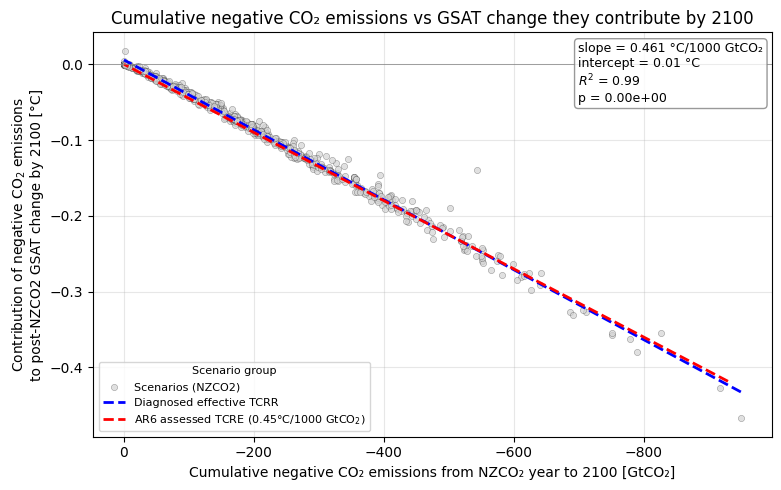

In [29]:
# Linear regression
plot_data = plot_data[plot_data["cumulative_netnegative_co2"]<0]
x = plot_data["cumulative_netnegative_co2"].values
y = plot_data["GSAT|CO2_Negative|delta_netzero_co2"].values
slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept
# Assessed TCRE reference line: 0.45°C per 1000 GtCO2, intercept 0
tcre_slope = 0.45 / 1000  # °C per GtCO2
x_tcre = np.linspace(-930, 0, 100)
y_tcre = tcre_slope * x_tcre

color_map = {
    "Scenarios (NZCO2)": "lightgrey",
 #   "Scenarios (NZGHG)": "lightgrey"
}

fig, ax = plt.subplots(figsize=(8, 5))

for group, marker in color_map.items():
    gdata = plot_data[plot_data["scenario_group"] == group]
    if gdata.empty:
        continue
    ax.scatter(
        gdata["cumulative_netnegative_co2"],
        gdata["GSAT|CO2_Negative|delta_netzero_co2"],
        color=color_map[group],
        alpha=0.7,
        s=20,
        edgecolors="black",
        linewidths=0.2,
        label=group,
    )

# Regression line
ax.plot(x_fit, y_fit, color="blue", linewidth=2, linestyle="--", label="Diagnosed effective TCRR")
ax.plot(x_tcre, y_tcre, color="red", linewidth=2, linestyle="--", label="AR6 assessed TCRE (0.45°C/1000 GtCO$_2$)")

ax.invert_xaxis()
# Regression stats text
ax.text(
    0.715, 0.975,
    f"slope = {1000*slope:.3f} °C/1000 GtCO₂\nintercept = {intercept:.2f} °C\n$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)
ax.set_xlabel("Cumulative negative CO₂ emissions from NZCO₂ year to 2100 [GtCO₂]")
ax.set_ylabel("Contribution of negative CO$_2$ emissions\nto post-NZCO2 GSAT change by 2100 [°C]")
ax.set_title("Cumulative negative CO₂ emissions vs GSAT change they contribute by 2100")
ax.legend(title="Scenario group", fontsize=8, title_fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "503_negative_co2.png", dpi=300, bbox_inches="tight")
plt.show()

## Separately assess highest and lowest sensitivity parts of the scenarios

In [30]:
def select_percentile_members(metrics_df, ranking_col="GSAT|ANTHROPOGENIC|2100", low=0.10, high=0.90):
    """
    Within each scenario, rank run_ids by ranking_col and return
    two subsets: bottom `low` fraction and top `high` fraction.
    """
    def rank_and_split(group):
        n = len(group)
        sorted_group = group.sort_values(ranking_col)
        n_low = max(1, int(np.floor(n * low)))
        n_high = max(1, int(np.floor(n * (1 - high))))
        return sorted_group.iloc[:n_low], sorted_group.iloc[-n_high:]
        
    low_members, high_members = [], []
    for _, group in metrics_df.groupby(["model", "scenario", "scenario_group"]):
        lo, hi = rank_and_split(group)
        low_members.append(lo)
        high_members.append(hi)

    return pd.concat(low_members, ignore_index=True), pd.concat(high_members, ignore_index=True)


metrics_df_p10, metrics_df_p90 = select_percentile_members(
    metrics_df, ranking_col="GSAT|ANTHROPOGENIC|2100", low=0.10, high=0.90
)

print(f"P10 subset: {len(metrics_df_p10)} rows across {metrics_df_p10.groupby(['model','scenario']).ngroups} scenarios")
print(f"P90 subset: {len(metrics_df_p90)} rows across {metrics_df_p90.groupby(['model','scenario']).ngroups} scenarios")

P10 subset: 140520 rows across 1955 scenarios
P90 subset: 138178 rows across 1955 scenarios


## for 90th percentile members

In [31]:
# now run the waterfall plots for these subsets of metrics_df

### for NZCO2 year
# Define delta columns and percentiles to calculate
delta_cols = [f"GSAT|{c}|delta_netzero_co2" for c in COMPONENTS if f"GSAT|{c}|delta_netzero_co2" in metrics_df_p90.columns]
PERCENTILES = {"median": 0.5, "p05": 0.05, "p34": 0.34, "p67": 0.67, "p95": 0.95}

# Calculate per-scenario percentiles for each delta column
scenario_percentiles = metrics_df_p90.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
    [lambda x, q=q: x.quantile(q) for q in PERCENTILES.values()]
)
scenario_percentiles.columns = [f"{col}|{name}" for col in delta_cols for name in PERCENTILES.keys()]

print(f"Calculated percentiles for {len(scenario_percentiles)} scenarios")
scenario_percentiles.head(10)

pop_by_group_netzero_co2 = calc_pop_by_group(scenario_percentiles, COMPONENTS, "netzero_co2")

Calculated percentiles for 2342 scenarios


KeyError: 'GSAT|ANTHROPOGENIC|delta_netzero_co2|p17'

In [ ]:
# Calculate scenario-level medians for peak and 2100 (needed for waterfall endpoints)
value_cols = [c for c in metrics_df_p90.columns if c.startswith("GSAT|")]
scenario_medians = metrics_df_p90.groupby(["model", "scenario", "scenario_group"])[value_cols].median()

# Filter to Base scenarios using scenario_group column
scenario_medians_nzco2 = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Base (NZCO2)"
]

# Filter to NZKyoto_syn scenarios using scenario_group column
scenario_medians_nzco2_syn = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "NZCO2_syn"
]

# Filter to NZKyoto scenarios using scenario_group column
scenario_medians_nzkyoto = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Base (NZGHG)"
]

# Filter to NZKyoto_syn scenarios using scenario_group column
scenario_medians_nzkyoto_syn = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "NZKyoto_syn"
]

print(f"All scenarios: {len(scenario_medians)}")
print(f"  Peak (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero CO2 scenarios: {len(scenario_medians_nzco2)}")
print(f"  Peak (median of medians): {scenario_medians_nzco2['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzco2['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero CO2_syn scenarios: {len(scenario_medians_nzco2_syn)}")
print(f"  Peak (median of medians): {scenario_medians_nzco2_syn['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzco2_syn['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero Kyoto scenarios: {len(scenario_medians_nzkyoto)}")
print(f"  Peak (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero Kyoto_syn scenarios: {len(scenario_medians_nzkyoto_syn)}")
print(f"  Peak (median of medians): {scenario_medians_nzkyoto_syn['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzkyoto_syn['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

In [ ]:
pop_by_group = pop_by_group_netzero_co2
#pop_by_group = pop_by_group_peak_gsat


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()  # convert 2x2 array to flat array of 4 axes

groups = ["Base (NZCO2)", "Base (NZGHG)", "NZCO2_syn", "NZKyoto_syn"]
scenario_medians_by_group = {
    "Base (NZCO2)":  scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Base (NZCO2)"],
    "Base (NZGHG)":  scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Base (NZGHG)"],
    "NZCO2_syn":     scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "NZCO2_syn"],
    "NZKyoto_syn":   scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "NZKyoto_syn"],
}

for ax, group in zip(axes, groups):
    create_waterfall_plot(
        pop_by_group[group],
        scenario_medians_by_group[group],
        f"{group} (n={len(scenario_medians_by_group[group])})",
        ax
    )

# Only left-hand panels need y-axis label
for ax in axes[1::2]:  # axes 1 and 3 (right column)
    ax.set_ylabel("")
    ax.set_ylim(1,2.8)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "503_waterfall_contributions_nzco2_p90_1.png", dpi=150, bbox_inches="tight")
plt.show()

## and for 10th percentile

In [ ]:
# now run the waterfall plots for these subsets of metrics_df

### for NZCO2 year
# Define delta columns and percentiles to calculate
delta_cols = [f"GSAT|{c}|delta_netzero_co2" for c in COMPONENTS if f"GSAT|{c}|delta_netzero_co2" in metrics_df_p10.columns]
PERCENTILES = {"median": 0.5, "p05": 0.05, "p34": 0.34, "p67": 0.67, "p95": 0.95}

# Calculate per-scenario percentiles for each delta column
scenario_percentiles = metrics_df_p10.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
    [lambda x, q=q: x.quantile(q) for q in PERCENTILES.values()]
)
scenario_percentiles.columns = [f"{col}|{name}" for col in delta_cols for name in PERCENTILES.keys()]

print(f"Calculated percentiles for {len(scenario_percentiles)} scenarios")
scenario_percentiles.head(10)

pop_by_group_netzero_co2 = calc_pop_by_group(scenario_percentiles, COMPONENTS, "netzero_co2")


### for peak GSAT year
# Define delta columns and percentiles to calculate
delta_cols = [f"GSAT|{c}|delta_peak_gsat" for c in COMPONENTS if f"GSAT|{c}|delta_peak_gsat" in metrics_df_p10.columns]
PERCENTILES = {"median": 0.5, "p05": 0.05, "p34": 0.34, "p67": 0.67, "p95": 0.95}

# Calculate per-scenario percentiles for each delta column
scenario_percentiles = metrics_df_p10.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
    [lambda x, q=q: x.quantile(q) for q in PERCENTILES.values()]
)
scenario_percentiles.columns = [f"{col}|{name}" for col in delta_cols for name in PERCENTILES.keys()]

print(f"Calculated percentiles for {len(scenario_percentiles)} scenarios")
scenario_percentiles.head(10)

pop_by_group_peak_gsat = calc_pop_by_group(scenario_percentiles, COMPONENTS, "peak_gsat")

In [ ]:
# Calculate scenario-level medians for peak and 2100 (needed for waterfall endpoints)
value_cols = [c for c in metrics_df_p10.columns if c.startswith("GSAT|")]
scenario_medians = metrics_df_p10.groupby(["model", "scenario", "scenario_group"])[value_cols].median()

# Filter to Base scenarios using scenario_group column
scenario_medians_nzco2 = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Base (NZCO2)"
]

# Filter to NZKyoto_syn scenarios using scenario_group column
scenario_medians_nzco2_syn = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "NZCO2_syn"
]

# Filter to NZKyoto scenarios using scenario_group column
scenario_medians_nzkyoto = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "Base (NZGHG)"
]

# Filter to NZKyoto_syn scenarios using scenario_group column
scenario_medians_nzkyoto_syn = scenario_medians[
    scenario_medians.index.get_level_values("scenario_group") == "NZKyoto_syn"
]

print(f"All scenarios: {len(scenario_medians)}")
print(f"  Peak (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero CO2 scenarios: {len(scenario_medians_nzco2)}")
print(f"  Peak (median of medians): {scenario_medians_nzco2['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzco2['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero CO2_syn scenarios: {len(scenario_medians_nzco2_syn)}")
print(f"  Peak (median of medians): {scenario_medians_nzco2_syn['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzco2_syn['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero Kyoto scenarios: {len(scenario_medians_nzkyoto)}")
print(f"  Peak (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzkyoto['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

print(f"\nNet-zero Kyoto_syn scenarios: {len(scenario_medians_nzkyoto_syn)}")
print(f"  Peak (median of medians): {scenario_medians_nzkyoto_syn['GSAT|ANTHROPOGENIC|peak'].median():.3f} °C")
print(f"  2100 (median of medians): {scenario_medians_nzkyoto_syn['GSAT|ANTHROPOGENIC|2100'].median():.3f} °C")

In [ ]:
pop_by_group = pop_by_group_netzero_co2
#pop_by_group = pop_by_group_peak_gsat


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()  # convert 2x2 array to flat array of 4 axes

groups = ["Base (NZCO2)", "Base (NZGHG)", "NZCO2_syn", "NZKyoto_syn"]
scenario_medians_by_group = {
    "Base (NZCO2)":  scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Base (NZCO2)"],
    "Base (NZGHG)":  scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "Base (NZGHG)"],
    "NZCO2_syn":     scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "NZCO2_syn"],
    "NZKyoto_syn":   scenario_medians[scenario_medians.index.get_level_values("scenario_group") == "NZKyoto_syn"],
}

for ax, group in zip(axes, groups):
    create_waterfall_plot(
        pop_by_group[group],
        scenario_medians_by_group[group],
        f"{group} (n={len(scenario_medians_by_group[group])})",
        ax
    )

# Only left-hand panels need y-axis label
for ax in axes[1::2]:  # axes 1 and 3 (right column)
    ax.set_ylabel("")
    ax.set_ylim(0.7,1.5)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "503_waterfall_contributions_nzco2_p10_07.png", dpi=150, bbox_inches="tight")
plt.show()

## climate uncertainty statistic

In [32]:
# Compute ZEC50 per member
metrics_df["ZEC50"] = (
    metrics_df["GSAT|CO2_NZCO2|delta_netzero_co2"]
    * 50
    / (2100 - metrics_df["year_netzero_co2"])
)

# Within-scenario spread of ZEC50 (climate uncertainty per scenario)
within_scenario_spread = metrics_df.groupby(["model", "scenario", "scenario_group"])[
    "ZEC50"
].agg(
    median="median",
    p17=lambda x: x.quantile(0.17),
    p83=lambda x: x.quantile(0.83),
#    p10=lambda x: x.quantile(0.10),
#    p90=lambda x: x.quantile(0.90),
#    p05=lambda x: x.quantile(0.05),
#    p95=lambda x: x.quantile(0.95),
    spread_17_83=lambda x: x.quantile(0.83) - x.quantile(0.17),
).reset_index()

# Summary across scenarios per group
summary = within_scenario_spread.groupby("scenario_group").agg(
    n_scenarios=("median", "count"),
    median_of_medians=("median", "median"),
    median_p17=("p17", "median"),
    median_p83=("p83", "median"),
#    median_p10=("p10", "median"),
#    median_p90=("p90", "median"),
#    median_p05=("p05", "median"),
#    median_p95=("p95", "median"),
    median_spread_17_83=("spread_17_83", "median"),
).round(3)

print("Climate uncertainty in ZEC50 (within-scenario spread, median across scenarios):")
summary

Climate uncertainty in ZEC50 (within-scenario spread, median across scenarios):


,n_scenarios,median_of_medians,median_p17,median_p83,median_spread_17_83
scenario_group,,,,,
Scenarios (NZCO2),784,-0.053,-0.102,0.040,0.140
Scenarios (NZGHG),387,-0.058,-0.108,0.039,0.148
Stylised Variants (NZCO2-hold),784,-0.053,-0.102,0.040,0.140
Stylised Variants (NZGHG-hold),387,-0.058,-0.108,0.039,0.148


In [33]:
within_scenario_spread

,model,scenario,scenario_group,median,p17,p83,spread_17_83
0,AIM/CGE 2.0,SSP1-19,Scenarios (NZCO2),-0.072069,-0.110964,0.004042,0.115006
1,AIM/CGE 2.0,SSP1-19,Scenarios (NZGHG),-0.072069,-0.110964,0.004042,0.115006
2,AIM/CGE 2.0,SSP1-19_NZCO2,Stylised Variants (NZCO2-hold),-0.072069,-0.110964,0.004042,0.115006
3,AIM/CGE 2.0,SSP1-19_NZKyoto,Stylised Variants (NZGHG-hold),-0.072069,-0.110964,0.004042,0.115006
4,AIM/CGE 2.0,SSP2-19,Scenarios (NZCO2),-0.076108,-0.114752,-0.006216,0.108536
...,...,...,...,...,...,...,...
2337,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000_NZKyoto,Stylised Variants (NZGHG-hold),-0.086247,-0.126769,-0.025310,0.101459
2338,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,Scenarios (NZCO2),-0.057739,-0.097593,0.018629,0.116222
2339,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400,Scenarios (NZGHG),-0.057739,-0.097593,0.018629,0.116222
2340,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_400_NZCO2,Stylised Variants (NZCO2-hold),-0.057739,-0.097593,0.018629,0.116222


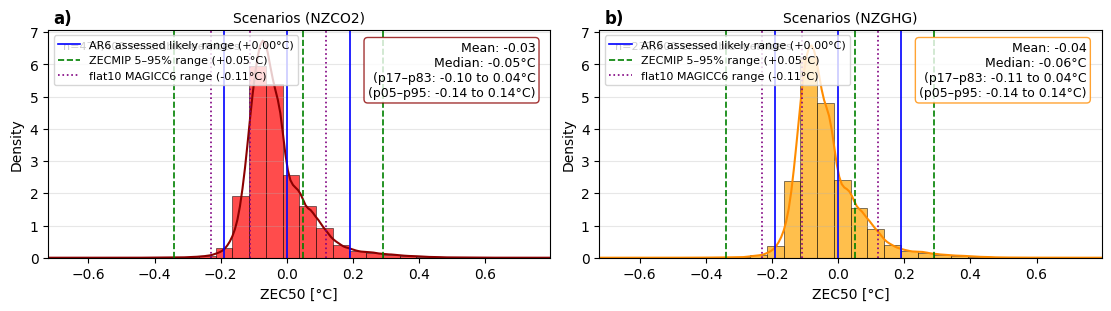

In [34]:
# Use full member pool (not scenario medians) for ZEC50
metrics_df["ZEC50"] = (
    metrics_df["GSAT|CO2_NZCO2|delta_netzero_co2"]
    * 50
    / (2100 - metrics_df["year_netzero_co2"])
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3), constrained_layout=True)

groups = ["Scenarios (NZCO2)", "Scenarios (NZGHG)"]
colors = {
    "Scenarios (NZCO2)": "red",
    "Scenarios (NZGHG)": "orange",
}
kde_colors = {
    "Scenarios (NZCO2)": "darkred",
    "Scenarios (NZGHG)": "darkorange",
}

# Shared x-axis range from full member pool
zec50_all = metrics_df[metrics_df["scenario_group"].isin(groups)]["ZEC50"].dropna()
x_min, x_max = zec50_all.min(), zec50_all.max()
x_range = np.linspace(x_min, x_max, 200)

for ax, group in zip(axes, groups):
    gdata = metrics_df[metrics_df["scenario_group"] == group]["ZEC50"].dropna()
    color = colors[group]
    kde_color = kde_colors[group]

    # Percentiles
    mean = gdata.mean()
    p05 = gdata.quantile(0.05)
    p17 = gdata.quantile(0.17)
    p50 = gdata.median()
    p83 = gdata.quantile(0.83)
    p95 = gdata.quantile(0.95)

    ax.hist(
        gdata,
        bins=30,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.7,
        density=True,
    )

    # KDE overlay
    if len(gdata) > 1:
        kde = gaussian_kde(gdata)
        ax.plot(x_range, kde(x_range), color=kde_color, linewidth=1.5)

    # Vertical lines for median and p17/p83
    #  ax.axvline(p50, color=kde_color, linestyle="-",  linewidth=1.2)
    #  ax.axvline(p17, color=kde_color, linestyle=":",  linewidth=1.2)
    #  ax.axvline(p83, color=kde_color, linestyle=":",  linewidth=1.2)
    # Vertical line groups
    vline_groups = {
        "AR6 assessed likely range":    {"values": [-0.19, 0.0,  0.19], "color": "blue",   "linestyle": "-"},
        "ZECMIP 5–95% range":           {"values": [-0.34, 0.05, 0.29], "color": "green",  "linestyle": "--"},
        "flat10 MAGICC6 range":         {"values": [-0.23, -0.11, 0.12], "color": "purple", "linestyle": ":"},
    }

    for label, cfg in vline_groups.items():
        for i, val in enumerate(cfg["values"]):
            ax.axvline(
                val,
                color=cfg["color"],
                linestyle=cfg["linestyle"],
                linewidth=1.2,
                # Only add label to the middle line (central value) to avoid legend duplication
                label=f"{label} ({val:+.2f}°C)" if i == 1 else None,
            )

    ax.legend(fontsize=8, loc="upper left", frameon=True, framealpha=0.8)
    # Text annotation
    ax.annotate(
        f"Mean: {mean:.2f}\nMedian: {p50:.2f}°C\n(p17–p83: {p17:.2f} to {p83:.2f}°C\n(p05–p95: {p05:.2f} to {p95:.2f}°C)",
        xy=(0.97, 0.95),
        xycoords="axes fraction",
        fontsize=9,
        va="top",
        ha="right",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=kde_color, alpha=0.8)
    )

    ax.set_xlim(x_min, x_max)
    ax.set_title(group, fontsize=10)
    ax.set_xlabel("ZEC50 [°C]")
    ax.set_ylabel("Density")
    ax.grid(alpha=0.3, axis="y")
    ax.annotate(
        f"n={len(gdata):,} ensemble members",
        xy=(0.03, 0.95),
        xycoords="axes fraction",
        fontsize=8,
        va="top",
        ha="left",
    )

# Align y-axis limits
ymax = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(0, ymax)

# Panel labels
for ax, label in zip(axes, ["a)", "b)"]):
    ax.annotate(label, xy=(0.01, 1.09), xycoords="axes fraction",
                fontsize=12, fontweight="bold", va="top", ha="left")

plt.savefig(PLOT_FOLDER / "503_ZEC50_member_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

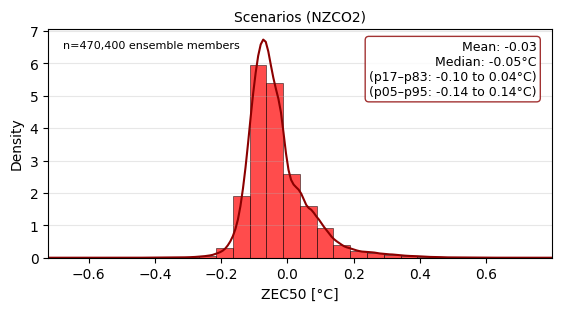

In [35]:
# Use full member pool (not scenario medians) for ZEC50
metrics_df["ZEC50"] = (
    metrics_df["GSAT|CO2_NZCO2|delta_netzero_co2"]
    * 50
    / (2100 - metrics_df["year_netzero_co2"])
)

fig, ax = plt.subplots(figsize=(5.5, 3), constrained_layout=True)

group = "Scenarios (NZCO2)"
color = "red"
kde_color = "darkred"

# Shared x-axis range from full member pool
gdata = metrics_df[metrics_df["scenario_group"] == group]["ZEC50"].dropna()
x_min, x_max = gdata.min(), gdata.max()
x_range = np.linspace(x_min, x_max, 200)

# Percentiles
mean = gdata.mean()
p05 = gdata.quantile(0.05)
p17 = gdata.quantile(0.17)
p50 = gdata.median()
p83 = gdata.quantile(0.83)
p95 = gdata.quantile(0.95)

ax.hist(
    gdata,
    bins=30,
    color=color,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.7,
    density=True,
)

if len(gdata) > 1:
    kde = gaussian_kde(gdata)
    ax.plot(x_range, kde(x_range), color=kde_color, linewidth=1.5)

ax.annotate(
    f"Mean: {mean:.2f}\nMedian: {p50:.2f}°C\n(p17–p83: {p17:.2f} to {p83:.2f}°C)\n(p05–p95: {p05:.2f} to {p95:.2f}°C)",
    xy=(0.97, 0.95),
    xycoords="axes fraction",
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=kde_color, alpha=0.8)
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(0, None)
ax.set_title(group, fontsize=10)
ax.set_xlabel("ZEC50 [°C]")
ax.set_ylabel("Density")
ax.grid(alpha=0.3, axis="y")
ax.annotate(
    f"n={len(gdata):,} ensemble members",
    xy=(0.03, 0.95),
    xycoords="axes fraction",
    fontsize=8,
    va="top",
    ha="left",
)

plt.savefig(PLOT_FOLDER / "503_ZEC50_validation.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
metrics_df[metrics_df["scenario_group"]=="Scenarios (NZCO2)"]["ZEC50"].quantile(0.83)

np.float64(0.04132269424419567)

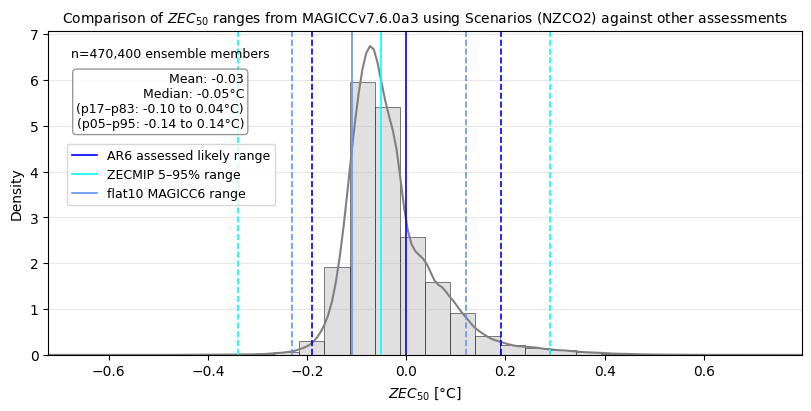

In [37]:
# Use full member pool (not scenario medians) for ZEC50
metrics_df["ZEC50"] = (
    metrics_df["GSAT|CO2_NZCO2|delta_netzero_co2"]
    * 50
    / (2100 - metrics_df["year_netzero_co2"])
)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

group = "Scenarios (NZCO2)"
color = "lightgrey"
kde_color = "gray"

# Shared x-axis range from full member pool
gdata = metrics_df[metrics_df["scenario_group"] == group]["ZEC50"].dropna()
x_min, x_max = gdata.min(), gdata.max()
x_range = np.linspace(x_min, x_max, 200)

# Percentiles
mean = gdata.mean()
p05 = gdata.quantile(0.05)
p17 = gdata.quantile(0.17)
p50 = gdata.median()
p83 = gdata.quantile(0.83)
p95 = gdata.quantile(0.95)

ax.hist(
    gdata,
    bins=30,
    color=color,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.7,
    density=True,
)

if len(gdata) > 1:
    kde = gaussian_kde(gdata)
    ax.plot(x_range, kde(x_range), color=kde_color, linewidth=1.5)


# Vertical line groups
vline_groups = {
    "AR6 assessed likely range": {"values": [-0.19, 0.0,  0.19], "color": "blue"},
    "ZECMIP 5–95% range":        {"values": [-0.34, -0.05, 0.29], "color": "cyan"},
    "flat10 MAGICC6 range":      {"values": [-0.23, -0.11, 0.12], "color": "cornflowerblue"},
}

for label, cfg in vline_groups.items():
    for i, val in enumerate(cfg["values"]):
        linestyle = "-" if i == 1 else "--"
        ax.axvline(
            val,
            color=cfg["color"],
            linestyle=linestyle,
            linewidth=1.2,
        )

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="blue",   linestyle="-",  linewidth=1.2, label="AR6 assessed likely range"),
    Line2D([0], [0], color="cyan",  linestyle="-",  linewidth=1.2, label="ZECMIP 5–95% range"),
    Line2D([0], [0], color="cornflowerblue", linestyle="-",  linewidth=1.2, label="flat10 MAGICC6 range"),
]

ax.legend(
    handles=legend_handles,
    fontsize=9,
    frameon=True,
    framealpha=0.8,
    bbox_to_anchor=(0.163, 0.67),  # (x, y) in axes fraction coordinates
    loc="upper center",           # which part of the legend box sits at the anchor point
)

ax.annotate(
    f"Mean: {mean:.2f}\nMedian: {p50:.2f}°C\n(p17–p83: {p17:.2f} to {p83:.2f}°C)\n(p05–p95: {p05:.2f} to {p95:.2f}°C)",
    xy=(0.26, 0.87),
    xycoords="axes fraction",
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=kde_color, alpha=0.8)
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(0, None)
ax.set_title("Comparison of $ZEC_{50}$ ranges from MAGICCv7.6.0a3 using Scenarios (NZCO2) against other assessments", fontsize=10)
ax.set_xlabel("$ZEC_{50}$ [°C]")
ax.set_ylabel("Density")
ax.grid(alpha=0.3, axis="y")
ax.annotate(
    f"n={len(gdata):,} ensemble members",
    xy=(0.03, 0.95),
    xycoords="axes fraction",
    fontsize=9,
    va="top",
    ha="left",
)

plt.savefig(PLOT_FOLDER / "503_ZEC50_validation.png", dpi=300, bbox_inches="tight")
plt.show()